<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

This submission is a really solid and well-structured solution.

 - The entire notebook executes without errors, and provides answers to all tasks in a well-formatted way. 
 
 - The results are easy to read, with interpretations to underline the economic theory of the model. Each task is sectioned with markdown-cells to seperate, and additional details to structure the notebook. The code itself is clean and easy to follow, but could benefit from additional details to describe each step of action.

 - Functions are used where appropriate to avoid reuse and duplication of code. Helper functions are defined in part 1, and used throughout the notebook to do fundamental parts of the code, which contributes to a clear and well-presented solution.

 - Although vectorization could be used to benefit efficency, the model relies on loops to compute the model. As the model doesn't rely on heavy computations, loops are sufficient for the task.  Vectorization is used to a limited extent, mainly for simple array operations.

 - The solutions are correct according to the one posted on Canvas. Most of the numerical solutions are identical to those posted, while some differ because of rounding. The interpretations are also correct, although some could benefit from additional details to further demonstrate understanding.

 - I have not come up with a clearly better approach, as the solution is really well implemented!

# FIE463: Numerical Methods in Macroeconomics and Finance
## Term Paper 1 — Spring 2026
### Overlapping Generations Model with Workers and Capitalists

**Group:** [22]
**Candidates:** [32, 139, 162]  
**Deadline:** Wednesday, March 18, 2026


---
## Table of Contents
---

0. Setup and model build
1. **Part 1** — Euler Equation Errors
2. **Part 2** — Steady State Equilibrium
3. **Part 3** — Transition Dynamics
4. **Part 4** — Introduction of a Wealth Tax
5. **Part 5** — Social Welfare and Optimal Wealth Tax
6. **Part 6** — Uncertainty About Wealth Taxes

---
## 0. - Setup 
---


In [48]:
# Imports of all libraries required for the parts
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.optimize import root_scalar, minimize_scalar

plt.rcParams.update({"font.size": 12, "figure.figsize": (10, 6)})

---
## Part 1 - Euler Equation Errors
---

### 1.1 - Model build & Parameters
As the goal is to keep the code reusable, efficient, and non-duplicative, we dedicate the following part to building the full model setup.

In [49]:
@dataclass
class Parameters:
    # Preferences / technology
    beta: float = 0.99**30  # Discount factor (annual 0.99 over 30 years)
    gamma: float = 2.1  # RRA in utility
    tau: float = 0.3  # Payroll tax rate on workers
    phi: float = 0.5  # Fraction of wealth bequeathed by old capitalists
    alpha: float = 0.36  # Capital share in production
    delta: float = 1.0 - 0.94**30  # Depreciation rate (annual 6% over 30 years)
    z: float = 1.0  # TFP

    # Population shares
    Nw: float = 0.8  # Fraction of workers
    Nk: float = 0.2  # Fraction of capitalists

    # Wealth tax parameters
    tau_a: float = 0.0  # Wealth tax rate (Parts 4-6)

    # Part 6: uncertainty
    pi_a: float = 0.0  #
    tau_a_u: float = 0.05  #

In [50]:
par = Parameters()

In [51]:
# Test that parameters are correctly set
par

Parameters(beta=0.7397003733882802, gamma=2.1, tau=0.3, phi=0.5, alpha=0.36, delta=0.8437443938333354, z=1.0, Nw=0.8, Nk=0.2, tau_a=0.0, pi_a=0.0, tau_a_u=0.05)

### Helper Functions 
These helper functions collect the main components of the model and are used throughout the steady-state and transition analysis.



In [52]:
def util(c, par: Parameters):
    """
    Per-period CRRA utility.
    """
    if par.gamma == 1:
        return np.log(c)
    else:
        return c ** (1 - par.gamma) / (1 - par.gamma)

In [53]:
def marg_util(c, par: Parameters):
    """
    Marginal utility under CRRA preferences.
    """
    return c ** (-par.gamma)

In [54]:
def labor_supply(par: Parameters):
    """
    Aggregate labor supply from young workers.
    """
    return 0.5 * par.Nw

In [55]:
def production(K, par: Parameters):
    """
    Cobb-Douglas production function.
    """
    L = labor_supply(par)
    return par.z * K**par.alpha * L ** (1 - par.alpha)

In [56]:
def firm_prices(K, par: Parameters):
    """
    Return wage w and net interest rate r for given aggregate capital K.
    """
    L = labor_supply(par)

    w = (1 - par.alpha) * par.z * K**par.alpha * L ** (-par.alpha)
    r = par.alpha * par.z * K ** (par.alpha - 1) * L ** (1 - par.alpha) - par.delta

    return w, r

In [57]:
def pension(w, par: Parameters):
    """
    Old workers' pension from balanced social security budget.
    """
    return par.tau * w

In [58]:
def transfer(a_lag, r, par: Parameters, tau_a=None):
    """
    Lump-sum transfer from wealth tax revenue.

    a_lag is previous-period assets of the old capitalists.
    """
    if tau_a is None:
        tau_a = par.tau_a

    return 0.5 * par.Nk * tau_a * (1 + r) * a_lag

In [59]:
def worker_consumption(w, p_next, T_today, T_next, par: Parameters):
    """
    Workers consume disposable wage income plus transfer when young,
    and pension plus transfer when old.
    """
    c_y_w = (1 - par.tau) * w + T_today
    c_o_w = p_next + T_next

    return c_y_w, c_o_w

In [60]:
def capitalist_from_a(a, b, r_next, T_today, T_next, par: Parameters, tau_a=None):
    """
    Given savings a, compute capitalist allocations.
    """
    if tau_a is None:
        tau_a = par.tau_a

    c_y_k = b + T_today - a
    c_o_k = (1 - par.phi) * (1 - tau_a) * (1 + r_next) * a + T_next
    b_next = par.phi * (1 - tau_a) * (1 + r_next) * a

    return c_y_k, c_o_k, b_next

In [61]:
def implied_household_objects(K, K_next, par: Parameters, tau_a=None):
    """
    Map aggregate capital today and tomorrow into household-level objects.
    """
    if tau_a is None:
        tau_a = par.tau_a

    # Prices today and tomorrow
    w, r = firm_prices(K, par)
    w_next, r_next = firm_prices(K_next, par)

    # Capital market clearing:
    # K_t = (1/2) * N_k * a_{t-1}
    # K_{t+1} = (1/2) * N_k * a_t
    a_lag = 2 * K / par.Nk
    a = 2 * K_next / par.Nk

    # Government objects
    p = pension(w, par)
    p_next = pension(w_next, par)

    T_today = transfer(a_lag, r, par, tau_a=tau_a)
    T_next = transfer(a, r_next, par, tau_a=tau_a)

    # Bequests inherited by young capitalists today
    b = par.phi * (1 - tau_a) * (1 + r) * a_lag

    # Reuse helper functions
    c_y_w, c_o_w_next = worker_consumption(w, p_next, T_today, T_next, par)
    c_y_k, c_o_k_next, b_next = capitalist_from_a(
        a, b, r_next, T_today, T_next, par, tau_a=tau_a
    )

    # Old households today
    c_o_w_current = p + T_today
    c_o_k_current = (1 - par.phi) * (1 - tau_a) * (1 + r) * a_lag + T_today

    # Savings rate of young capitalists
    s = a / (b + T_today)

    return {
        "Y": production(K, par),
        "w": w,
        "r": r,
        "w_next": w_next, 
        "r_next": r_next,
        "a_lag": a_lag,
        "a": a,
        "b": b,
        "b_next": b_next,
        "p": p,
        "p_next": p_next,
        "T_today": T_today,
        "T_next": T_next,
        "s": s,
        "c_y_w": c_y_w,
        "c_y_k": c_y_k,
        "c_o_w_current": c_o_w_current,
        "c_o_k_current": c_o_k_current,
        "c_o_w_next": c_o_w_next,
        "c_o_k_next": c_o_k_next,
    }

In [62]:
def goods_mkt_err(K, K_next, par: Parameters, tau_a=None):
    """
    Goods market residual in period t.
    """
    obj = implied_household_objects(K, K_next, par, tau_a=tau_a)

    lhs = obj["Y"] + (1 - par.delta) * K
    rhs = 0.5 * par.Nw * (obj["c_y_w"] + obj["c_o_w_current"]) + 0.5 * par.Nk * (
        obj["c_y_k"] + obj["c_o_k_current"] + obj["a"]
    )

    return lhs - rhs

In [63]:
def find_bracket(par: Parameters, euler_fun=None, K_min=1e-4, K_max=0.05, nK=1000):
    """
    Find a valid sign change bracket for the steady state Euler equation.
    """
    if euler_fun is None:
        euler_fun = euler_err

    K_grid = np.linspace(K_min, K_max, nK)
    err_grid = np.full(nK, np.nan)

    for i, K in enumerate(K_grid):
        err_grid[i] = euler_fun(K, K, par)

    for i in range(nK - 1):
        f0 = err_grid[i]
        f1 = err_grid[i + 1]

        if np.isfinite(f0) and np.isfinite(f1) and f0 * f1 < 0:
            return K_grid[i], K_grid[i + 1]

    raise ValueError("No sign change found. Increase K_max or inspect Euler errors.")

### Part 1.2: Implement function euler_err

In [64]:
def euler_err(K_next, K, par: Parameters):
    """
    Compute the capitalists' Euler equation error for a given capital
    stock today and tomorrow.
    """
    obj = implied_household_objects(K, K_next, par)

    c_y_k = obj["c_y_k"]
    c_o_k_next = obj["c_o_k_next"]

    if c_y_k <= 0 or c_o_k_next <= 0:
        return np.nan

    lhs = marg_util(c_y_k, par)
    rhs = (
        par.beta
        * (1 + obj["r_next"])
        * (1 - par.tau_a)
        * (1 - par.phi)
        * marg_util(c_o_k_next, par)
    )

    return lhs - rhs


### Part 1.3: Plot the Euler equation errors

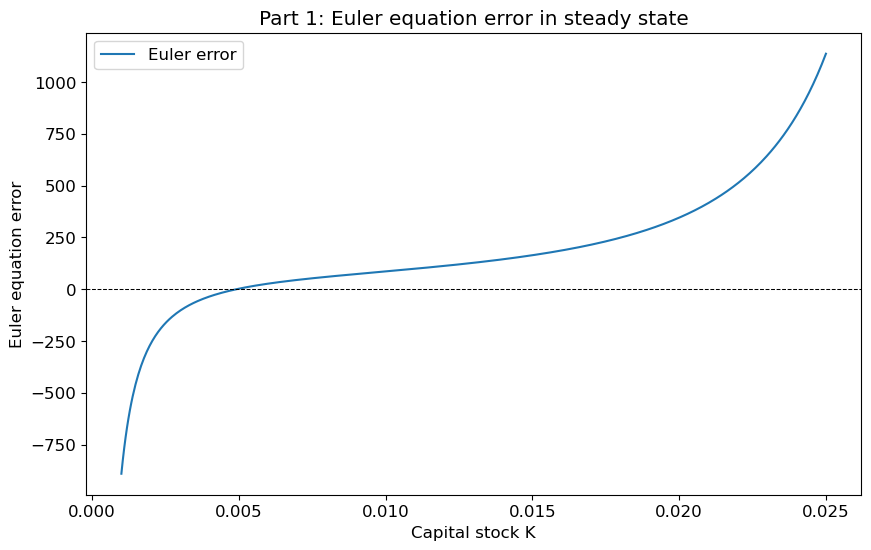

In [65]:
K_grid = np.linspace(0.001, 0.025, 500)
err_grid = np.empty(K_grid.size)

for i, K in enumerate(K_grid):
    err_grid[i] = euler_err(K, K, par)

fig, ax = plt.subplots()
ax.plot(K_grid, err_grid, label="Euler error")
ax.axhline(0.0, lw=0.75, ls="--", c="black")
ax.set_xlabel("Capital stock K")
ax.set_ylabel("Euler equation error")
ax.set_title("Part 1: Euler equation error in steady state")
ax.legend()
plt.show()

We plot Euler errors over a grid for $K$, assuming $K_{t+1}=K_t$, and verify a root where the error crosses zero.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 1:**

 - Part 1 executes without errors.

 - The plot is generally well structured, providing clear answers in a well-formatted way.

 - Helper functions is a good way to reuse the fundamental parts of the model and to avoid duplication, following a core principal of the given task. 
    - Although most of the helper functions are well structured and easy to follow, the function `implied_household_objects` is somewhat compact and combines multiple steps. As the helper functions are made to reuse code, this works, but this specific helper function could be split into multiple functions for each step. 
    - Doc-strings help document the smaller functions, but the larger functions could benefit from additional comments for each step of the function.

 - A for-loop is used to evaluate the Euler equation errors. While vectorization is a more efficient method for computing a large numbers of observations, this task only handles 500 iterations, making a loop sufficient.

 - The economic components are correct, modelling the correct answers according to the solution. As the task asks for a plot, this is a good answer, although a possible improvement could be to provide additional details regarding the what the Euler errors represent.

---
## Part 2 - Steady State Equilibrium
---

### Task 2.1 - Define class - SteadyState

In [66]:
@dataclass
class SteadyState:
    K: float = None  # Capital stock
    Y: float = None  # Aggregated output
    w: float = None  # Wage rate
    r: float = None  # interest rate
    b: float = None  # Bequest received by young capitalist
    a: float = None  # Savings by young capitalist
    p: float = None  # pension
    T_a: float = None  # Lump-sum wealth tax
    s: float = None  # Savings rate

    c_y_w: float = None  # Consumption young worker
    c_o_w: float = None  # Consumption old workers
    c_y_k: float = None  # Consumption young capitalist
    c_o_k: float = None  # Consumption old capitalist


### Task 2.2 - Implement function compute_steady_state

In [67]:
def compute_steady_state(
    par: Parameters, euler_fun=None, K_min=1e-4, K_max=0.05, nK=1000, do_print=True
):
    """
    Compute steady state equilibrium.
    """
    if euler_fun is None:
        euler_fun = euler_err

    K_lo, K_hi = find_bracket(par, euler_fun=euler_fun, K_min=K_min, K_max=K_max, nK=nK)

    sol = root_scalar(
        lambda K: euler_fun(K, K, par), bracket=[K_lo, K_hi], method="brentq"
    )
    K = sol.root

    out = implied_household_objects(K, K, par, tau_a=par.tau_a)
    gm_err = goods_mkt_err(K, K, par, tau_a=par.tau_a)

    if out["c_y_k"] <= 0 or out["c_o_k_current"] <= 0:
        raise ValueError(
            "Steady state is inadmissible: capitalist consumption is non-positive."
        )

    if do_print:
        print(f"Goods market residual in SS: {gm_err:.4e}")

    ss = SteadyState(
        K=K,
        Y=out["Y"],
        w=out["w"],
        r=out["r"],
        b=out["b"],
        a=out["a"],
        p=out["p"],
        T_a=out["T_today"],
        s=out["s"],
        c_y_w=out["c_y_w"],
        c_o_w=out["c_o_w_current"],
        c_y_k=out["c_y_k"],
        c_o_k=out["c_o_k_current"],
    )

    return ss

### Task 2.3 - Compute and report steady-state equilibrium

In [68]:
ss = compute_steady_state(par)
print(" ")
print("-------------------------------------")
print("Steady state equilibrium")
print("-------------------------------------")
print(f"Capital K       = {ss.K:.6f}")
print(f"Output Y        = {ss.Y:.6f}")
print(f"Wage w          = {ss.w:.6f}")
print(f"Interest r      = {ss.r:.6f}")
print(f"Bequest b       = {ss.b:.6f}")
print(f"Savings a       = {ss.a:.6f}")
print(f"Pension p       = {ss.p:.6f}")
print(f"T_a             = {ss.T_a:.6f}")
print(f"s               = {ss.s:.6f}")
print("-------------------------------------")
print(f"c_y_w           = {ss.c_y_w:.6f}")
print(f"c_o_w           = {ss.c_o_w:.6f}")
print(f"c_y_k           = {ss.c_y_k:.6f}")
print(f"c_o_k           = {ss.c_o_k:.6f}")

Goods market residual in SS: 0.0000e+00
 
-------------------------------------
Steady state equilibrium
-------------------------------------
Capital K       = 0.004922
Output Y        = 0.082129
Wage w          = 0.131407
Interest r      = 5.162944
Bequest b       = 0.151678
Savings a       = 0.049223
Pension p       = 0.039422
T_a             = 0.000000
s               = 0.324520
-------------------------------------
c_y_w           = 0.091985
c_o_w           = 0.039422
c_y_k           = 0.102456
c_o_k           = 0.151678


### Part 2.4 - Compute implied annual interest rates

In [69]:
# Compute the implied annual net interest rate from the 30-year net interest rate
r_annual = (1 + ss.r) ** (1 / 30) - 1

r = ss.r

# Print the implied annual net interest rate
print(f"Annualized net interest rate = {100 * r_annual:.4f}%")

Annualized net interest rate = 6.2493%


The steady state is the value of aggregate capital \(K^*\) for which the Euler equation holds with

$$
K_{t+1} = K_t = K^*.
$$

Numerically, we find a steady-state net interest rate of

$$
r^* = 5.163,
$$

over one 30-year model period. This corresponds to an annualized net interest rate of approximately

$$
(1+r^*)^{1/30} - 1 \approx 6.25\%.
$$

This is economically plausible: since one model period is long, a high net return over 30 years can still correspond to a reasonable annual interest rate.

The steady state is also internally consistent. The goods market residual is numerically zero, which confirms that production, consumption, and capital accumulation are mutually consistent in equilibrium.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 2:**

 - The program runs without errors.
 
 - The code is easy to follow, which contributes to a clear and consistent structure. The outputs of the code are easy to read, and contain all the information the task asks for.

 - The helper functions from part 1 are taken into use, fulfilling the goal of resuable code. Functions from part 1, such as `euler_err` are reused, as asked for in the task. The functions could again benefit from additional comments, as none of the steps are documented with inline comments.

 - Part 2 uses helper functions from part 1 such as `find_bracket`, which utilizes loops to eveluate the Euler equation over a grid. Vectorization could in theory be used here, but loops are sufficient for this task.

 - The numerical calculations are again in line with the suggested solution, with clear and solid markdown-comments to explain the model. Using the goods market clearing to verify the equilibrium underlines the solution, with clear interpretations to explain the economic theory. The explanation of the final output connects the solution to theory in a good manner.


---
## Part 3 - Transition Dynamics
---

### Task 3.1 - Create Simulation class 

In [70]:
@dataclass
class Simulation:
    K: np.ndarray = None  # Capital stock
    Y: np.ndarray = None  # Aggregated output
    w: np.ndarray = None  # Wage rate
    r: np.ndarray = None  # Interest rate
    b: np.ndarray = None  # Bequest received by young capitalists
    a: np.ndarray = None  # Savings by young capitalists
    p: np.ndarray = None  # Pension
    T_a: np.ndarray = None  # Lump-sum transfer from wealth tax
    s: np.ndarray = None  # Savings rate

    c_y_w: np.ndarray = None  # Young workers consumption
    c_o_w: np.ndarray = None  # Old workers consumption
    c_y_k: np.ndarray = None  # Young capitalists consumption
    c_o_k: np.ndarray = None  # Old capitalists consumption

    goods_mkt_err: np.ndarray = None  # Goods market residual

### Task 3.2 - Implement simulate_olg function

In [71]:
def allocate_simulation(T):
    """
    Allocate arrays for transition simulation.
    """
    sim = Simulation(
        K=np.empty(T + 1),
        Y=np.empty(T),
        w=np.empty(T),
        r=np.empty(T),
        b=np.empty(T),
        a=np.empty(T),
        p=np.empty(T),
        T_a=np.empty(T),
        s=np.empty(T),
        c_y_w=np.empty(T),
        c_o_w=np.empty(T),
        c_y_k=np.empty(T),
        c_o_k=np.empty(T),
        goods_mkt_err=np.empty(T),
    )
    return sim

In [72]:
def find_transition_bracket(
    K_t, par: Parameters, euler_fun=None, K_min=1e-4, K_max=0.05, nK=1000
):
    """
    Find a sign change bracket for the transition Euler equation.
    """
    if euler_fun is None:
        euler_fun = euler_err

    K_grid = np.linspace(K_min, K_max, nK)
    err_grid = np.full(nK, np.nan)

    for i, K_next in enumerate(K_grid):
        err_grid[i] = euler_fun(K_next, K_t, par)

    for i in range(nK - 1):
        f0 = err_grid[i]
        f1 = err_grid[i + 1]

        if np.isfinite(f0) and np.isfinite(f1) and f0 * f1 < 0:
            return K_grid[i], K_grid[i + 1]

    raise ValueError(f"No sign change found for K_t={K_t:.6f}.")

In [73]:
def simulate_olg(
    K0, T, par: Parameters, euler_fun=None, K_min=1e-4, K_max=0.05, nK=1000, tol=1.0e-8
):
    """
    Simulate transition dynamics for T periods.
    """
    if euler_fun is None:
        euler_fun = euler_err

    sim = allocate_simulation(T)
    sim.K[0] = K0

    for t in range(T):
        K_t = sim.K[t]

        # Find a valid bracket for K_{t+1}
        K_lo, K_hi = find_transition_bracket(
            K_t, par, euler_fun=euler_fun, K_min=K_min, K_max=K_max, nK=nK
        )

        # Solve Euler equation for K_{t+1}
        sol = root_scalar(
            lambda K_next: euler_fun(K_next, K_t, par),
            bracket=[K_lo, K_hi],
            method="brentq",
        )
        K_next = sol.root
        sim.K[t + 1] = K_next

        out = implied_household_objects(K_t, K_next, par, tau_a=par.tau_a)

        sim.Y[t] = out["Y"]
        sim.w[t] = out["w"]
        sim.r[t] = out["r"]
        sim.b[t] = out["b"]
        sim.a[t] = out["a"]
        sim.p[t] = out["p"]
        sim.T_a[t] = out["T_today"]
        sim.s[t] = out["s"]
        sim.c_y_w[t] = out["c_y_w"]
        sim.c_o_w[t] = out["c_o_w_current"]
        sim.c_y_k[t] = out["c_y_k"]
        sim.c_o_k[t] = out["c_o_k_current"]

        # Verify goods market clearing in each period
        sim.goods_mkt_err[t] = goods_mkt_err(K_t, K_next, par, tau_a=par.tau_a)

        if not np.isfinite(sim.goods_mkt_err[t]) or abs(sim.goods_mkt_err[t]) > tol:
            raise AssertionError(
                f"Goods market does not clear in period t={t}: {sim.goods_mkt_err[t]:.4e}"
            )

    return sim

### Task 3.3 - Verify steady state

In [74]:
# Set initial capital stock for simulation and number of periods to simulate
K0 = 0.5 * ss.K
T = 20

# Simulation of transition dynamics starting from K0 for T periods
sim = simulate_olg(K0, T, par)

# Print results from simulation
print("Simulation:")
print("------------------------------------------")
print(f"Initial capital:                 {sim.K[0]:.6f}")
print(f"Final capital after simulation:  {sim.K[-1]:.6f}")
print(f"Steady-state capital K:          {ss.K:.6f}")
print(f"Max abs goods-market residual:   {np.max(np.abs(sim.goods_mkt_err)):.4e}")

Simulation:
------------------------------------------
Initial capital:                 0.002461
Final capital after simulation:  0.004922
Steady-state capital K:          0.004922
Max abs goods-market residual:   1.3878e-17


In [75]:
print(
    f"Max abs goods market residual along transition = {np.max(np.abs(sim.goods_mkt_err)):.4e}"
)

Max abs goods market residual along transition = 1.3878e-17


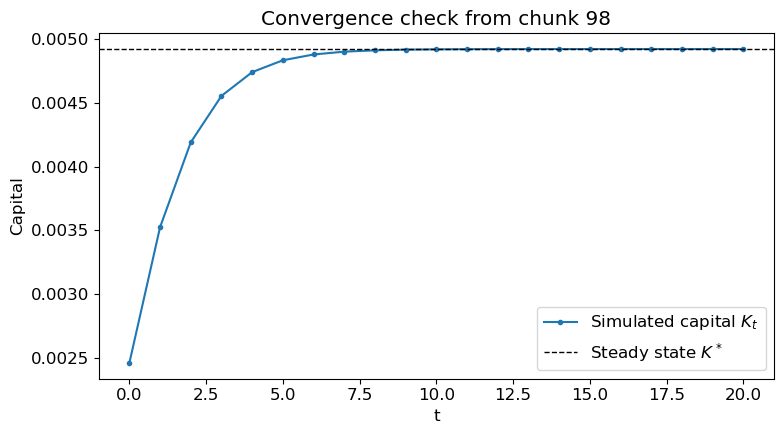

In [76]:
# Convergence of capital to steady state
plt.figure(figsize=(8, 4.5))
tgrid = np.arange(sim.K.size)

plt.plot(tgrid, sim.K, marker="o", ms=3, label="Simulated capital $K_t$")
plt.axhline(ss.K, color="black", ls="--", lw=1, label="Steady state $K^*$")

plt.xlabel("t")
plt.ylabel("Capital")
plt.title("Convergence check from chunk 98")
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation:

Starting from an initial capital stock below the steady state, \(K_0 = 0.5K^*\), the economy converges back toward the steady state over time. Capital, output, wages, bequests, and consumption all increase gradually toward their steady-state values, while the interest rate declines from a high initial level.

The economic intuition is standard: when capital is initially scarce, its marginal product is high, which implies a high interest rate. This strengthens the incentive to save, so capital accumulates over time. As the capital stock rises, output and wages increase, while the interest rate falls, and the economy approaches the steady state computed in Part 2.

### Task 3.4 - Transition Dynamics Plot
We plot the simulated series for all model variables as percentage deviations from the 
steady state, with $r$ and $s$ shown in levels.

In [77]:
def pct_dev(x, x_ss):
    """Return percentage deviation of x from steady-state value x_ss."""
    return 100 * (x / x_ss - 1)

In [78]:
def plot_simulation(sim: Simulation, ss_old: SteadyState, ss_new: SteadyState):
    """
    Plot transition dynamics.
    """
    t_flow = np.arange(sim.Y.size)
    t_cap = np.arange(sim.K.size)

    fig, axes = plt.subplots(5, 2, figsize=(12, 16))
    axes = axes.flatten()

    series = [
        (
            t_flow,
            pct_dev(sim.Y, ss_old.Y),
            0.0,
            pct_dev(ss_new.Y, ss_old.Y),
            "Output Y (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_cap,
            pct_dev(sim.K, ss_old.K),
            0.0,
            pct_dev(ss_new.K, ss_old.K),
            "Capital K (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_flow,
            pct_dev(sim.w, ss_old.w),
            0.0,
            pct_dev(ss_new.w, ss_old.w),
            "Wage w (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_flow,
            100 * sim.r,
            100 * ss_old.r,
            100 * ss_new.r,
            "Interest rate r (%)",
            "Percent (%)",
        ),
        (
            t_flow,
            100 * sim.s,
            100 * ss_old.s,
            100 * ss_new.s,
            "Savings rate s (%)",
            "Percent (%)",
        ),
        (
            t_flow,
            pct_dev(sim.b, ss_old.b),
            0.0,
            pct_dev(ss_new.b, ss_old.b),
            "Bequest b (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_flow,
            pct_dev(sim.c_y_w, ss_old.c_y_w),
            0.0,
            pct_dev(ss_new.c_y_w, ss_old.c_y_w),
            "Young workers cons. (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_flow,
            pct_dev(sim.c_o_w, ss_old.c_o_w),
            0.0,
            pct_dev(ss_new.c_o_w, ss_old.c_o_w),
            "Old workers cons. (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_flow,
            pct_dev(sim.c_y_k, ss_old.c_y_k),
            0.0,
            pct_dev(ss_new.c_y_k, ss_old.c_y_k),
            "Young capitalists cons. (% dev)",
            "Percent deviation (%)",
        ),
        (
            t_flow,
            pct_dev(sim.c_o_k, ss_old.c_o_k),
            0.0,
            pct_dev(ss_new.c_o_k, ss_old.c_o_k),
            "Old capitalists cons. (% dev)",
            "Percent deviation (%)",
        ),
    ]

    for ax, (t, y, y_old, y_new, title, ylabel) in zip(axes, series):
        ax.plot(t, y, lw=2, label="Transition path")
        ax.axhline(y_old, lw=1.0, ls="--", color="black", label="Old steady state")
        ax.axhline(y_new, lw=1.0, ls=":", color="black", label="New steady state")
        ax.set_title(title)
        ax.set_xlabel("Period")
        ax.set_ylabel(ylabel)
        ax.legend()

    fig.tight_layout()
    plt.show()

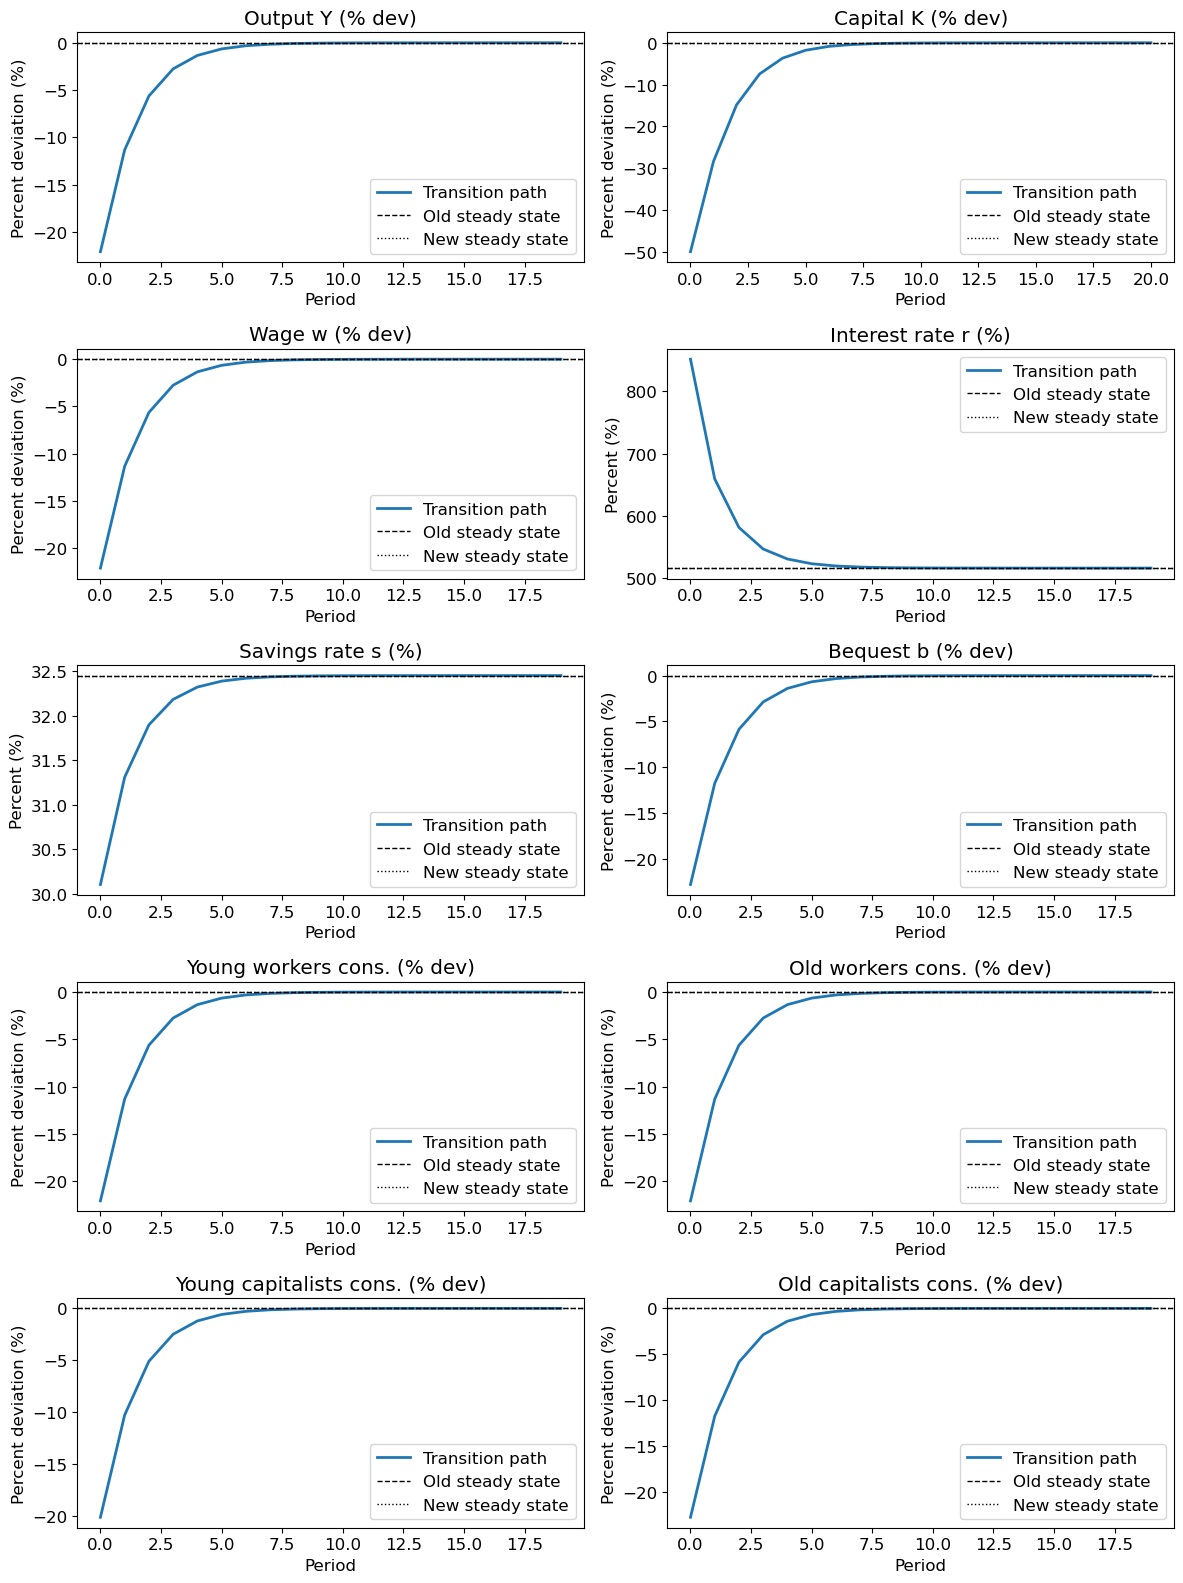

In [79]:
# Plot graphs of transition dynamics
plot_simulation(sim, ss, ss)

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 3:**

 - This part also executes  without errors, and presents the outputs in a clear and well-structured way. The code is easy to read and well formatted, with clear plots.

 - The implementation of the helper functions from part 1 and adaptation of `plot_simulation` directly answers the task, and avoids duplication of code. 

 - While looping over the 20 periods for the simulation in `simulate_olg` works fine for this number of iterations, vectorization could be used for improved efficiency. Vectorization is used in `pct_vars`.

 - The solutions are correct according to the solution from Canvas, with a solid interpretation of the simulation. The convergence check is a good verification of the model, indicating that the task is solved properly. 

 - As in prevoius parts, the functions used are well formatted and structured, but could again benefit from additional comments.

---
## Part 4 - Introduction of a Wealth Tax
---

### Tasks 4.1 & 4.2 - Parameters and Function Updates

To introduce the wealth tax, we set $\tau_a = 0.05$ and update the capitalist budget constraints. Bequests are now determined as a fraction of after-tax wealth:
$$b_{t+1} = \varphi(1-\tau_a)(1+r_{t+1})a_t$$

The capitalists' Euler equation is subsequently modified to incorporate the wealth tax $\tau_a$:
$$u'(b_t + T_{a,t} - a_t) = \beta(1+r_{t+1})(1-\tau_a)(1-\varphi)u'((1-\varphi)(1-\tau_a)(1+r_{t+1})a_t + T_{a,t+1})$$

*Implementation Note:* Instead of rewriting the functions entirely, we mapped the new parameters directly into our existing `euler_err`, `implied_household_objects`, and `compute_steady_state` functions to ensure code reusability and computational efficiency.

### Task 4.3 - New Steady State with Wealth Tax

In [ ]:
par_tax = Parameters(tau_a=0.05)
ss_tax = compute_steady_state(par_tax)

T = 20
sim_tax = simulate_olg(ss.K, T, par_tax)


print(" ")
print("Comparison of steady states:")
print("-------------------------------------------")
print(f"Old SS capital K:                {ss.K:.6f}")
print(f"New SS capital K:                {ss_tax.K:.6f}")
print(f"Old SS savings rate s:           {ss.s:.6f}")
print(f"New SS savings rate s:           {ss_tax.s:.6f}")
print(f"Max abs goods-market residual:   {np.max(np.abs(sim_tax.goods_mkt_err)):.4e}")

Goods market residual in SS: 1.3878e-17
 
Comparison of steady states:
-------------------------------------------
Old SS capital K:                0.004922
New SS capital K:                0.004572
Old SS savings rate s:           0.324520
New SS savings rate s:           0.322830
Max abs goods-market residual:   1.3878e-17


#### Interpretation - Task 4.3
Both capital and the savings rate fall in the new steady state ($K$ down 7.11%, $s$ down 
from 32.45% to 32.28%). The mechanism driving this change is that the wealth tax reduces the 
after-tax return on saving and shrinks bequests passed between capitalist generations. 
With less to inherit and a lower return on what they save, capitalists optimally choose 
to accumulate less. Lower aggregate saving means less capital in the economy.

### Tasks 4.4 & 4.5 - Transition Path and visualization

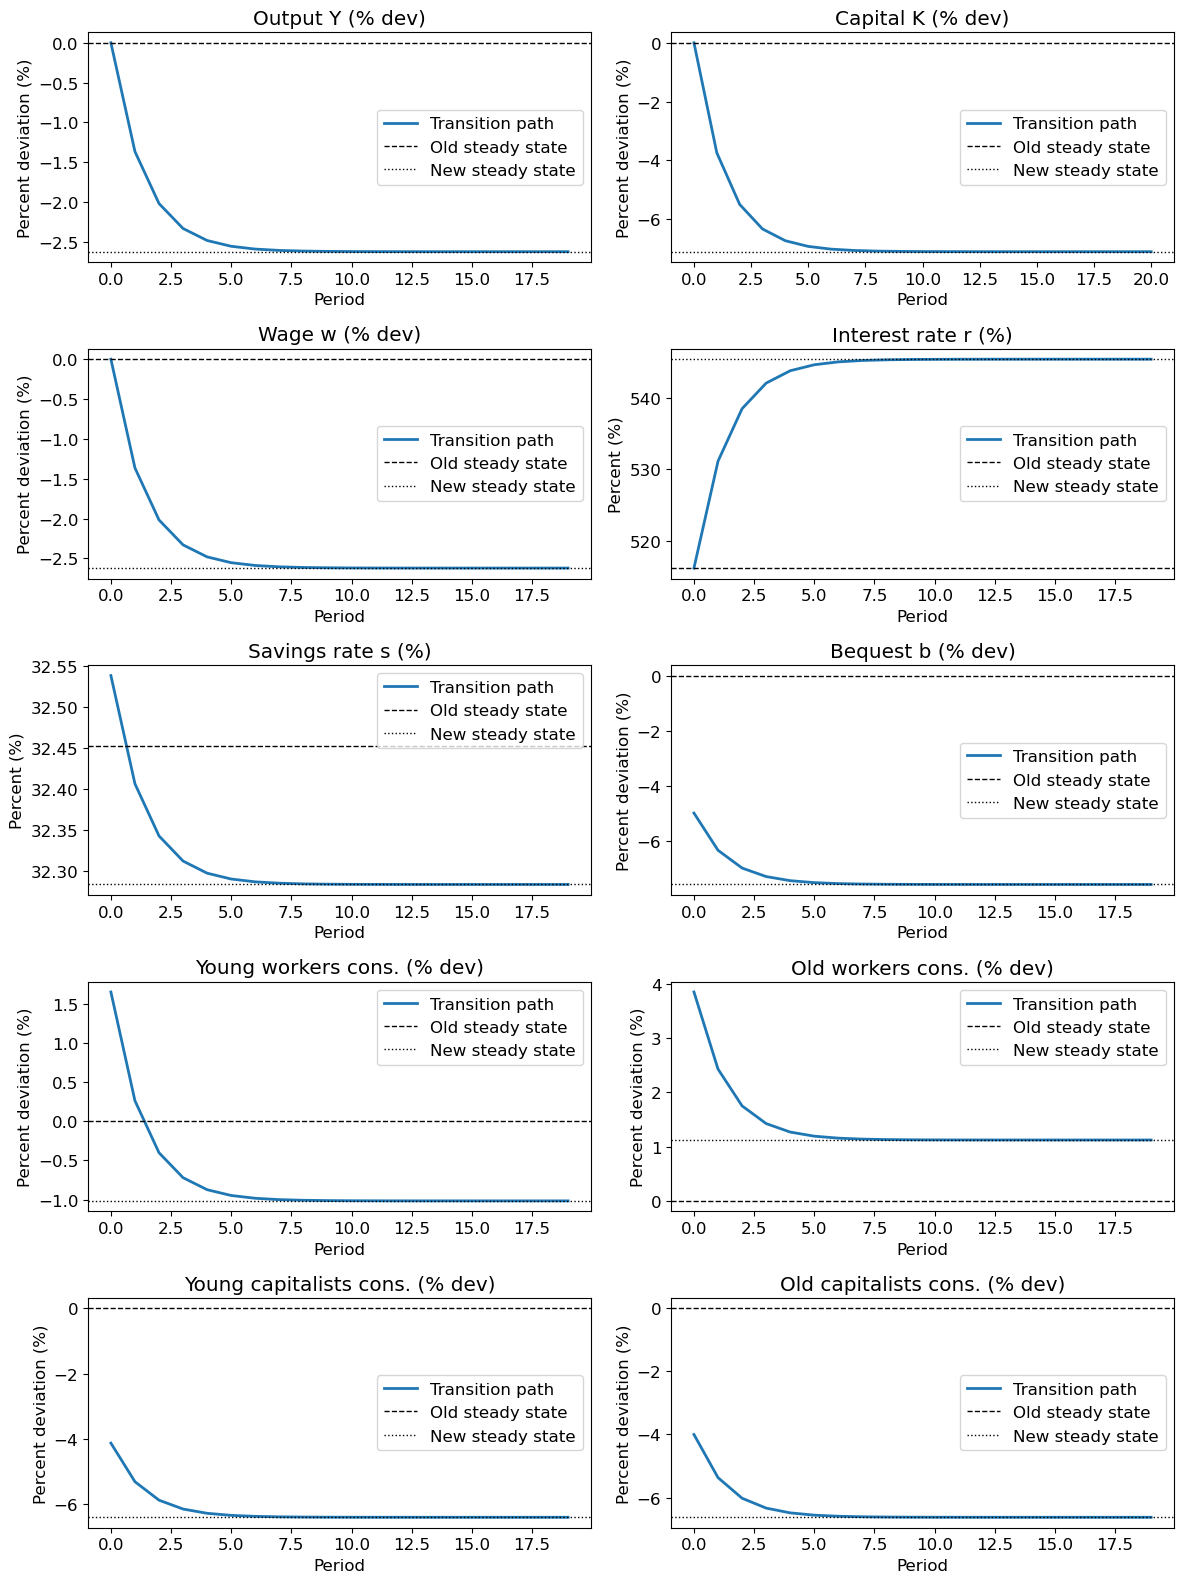

In [ ]:
# Set time periods
T = 20

# Simulation
sim_tax = simulate_olg(ss.K, T, par_tax)

# Plot simulation
plot_simulation(sim_tax, ss, ss_tax)

#### Comment on 4.5:
The plot confirms convergence: all variables transition smoothly from the old steady state to the new one within 20 periods. The savings rate drops on impact and remains flat at its new, lower steady-state level, reflecting the immediate behavioral adjustment to the new after-tax return on wealth.


In [ ]:
def impact_consumption_at_t0(K0, K1, par: Parameters):
    """
    Compute impact-period consumptions at t=0.
    """
    out = implied_household_objects(K0, K1, par, tau_a=par.tau_a)

    return {
        "c_y_w_0": out["c_y_w"],
        "c_y_k_0": out["c_y_k"],
        "c_old_worker_0": out["c_o_w_current"],
        "c_old_capitalist_0": out["c_o_k_current"],
    }


In [81]:
# Impact-period consumptions at t=0
K0 = ss.K
K1_no_tax = ss.K  # no-tax benchmark stays at old steady state
K1_tax = sim_tax.K[1]  # first transition-period capital under wealth tax

impact_no_tax = impact_consumption_at_t0(K0, K1_no_tax, par)
impact_tax = impact_consumption_at_t0(K0, K1_tax, par_tax)

# Compute max width for the first column
col_width = max(len(k) for k in impact_no_tax) + 2

print("Impact effects at t=0")
print("-" * 80)
print(
    f"{'Variable':<{col_width}} {'Baseline':>12} {'Tax':>12} {'Diff':>12} {'Pct':>10}"
)
print("-" * 80)

for key in impact_no_tax:
    base = impact_no_tax[key]
    new = impact_tax[key]
    diff = new - base
    pct = 100 * (new / base - 1)

    print(f"{key:<{col_width}} {base:>12.6f} {new:>12.6f} {diff:>12.6f} {pct:>9.2f}%")

Impact effects at t=0
--------------------------------------------------------------------------------
Variable                 Baseline          Tax         Diff        Pct
--------------------------------------------------------------------------------
c_y_w_0                  0.091985     0.093502     0.001517      1.65%
c_y_k_0                  0.102456     0.098232    -0.004223     -4.12%
c_old_worker_0           0.039422     0.040939     0.001517      3.85%
c_old_capitalist_0       0.151678     0.145611    -0.006067     -4.00%


### Interpretation: Task 4.6

Along the transition, old capitalists at $t = 0$ are hit hardest. They saved under the 
old regime but are immediately taxed, with no opportunity to adjust behaviour. Thus, the unanticipated taxes impose the largest burden on 
those who cannot respond (capitalists).

In the new steady state, capitalists are clear losers as lower bequests and after-tax 
returns permanently reduce their consumption. Workers lose slightly on wages as lower 
capital reduces labour productivity, but gain on transfers. The redistribution broadly 
offsets the wage loss, leaving workers roughly neutral.


<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 4:**

 - The code executes without errors, and presents results in a clear and well formatted way.

 - Use of markdown-cells to elaborate the model is both in line with the posted solution and makes the code easy to follow.

 - Functions are reused, and tax is incorporated to already existing functions, as asked for in the task.

 - A loop is used for printing results, which is more than sufficient for this task, avoiding the need for vectorization.

 - The solution is correct, and provides results for all variables asked for in the task. However, the solution could benefit from presenting additional variables in the new steady state, especially in task 4.3  (such as consumption or prices).

---
## Part 5 - Social Welfare and the Optimal Wealth Tax
---


### Task - 5.1: Social Welfare Comparison

In [ ]:
def welfare_components(ss: SteadyState, par: Parameters):
    """
    Welfare decomposition by household type in steady state.
    """
    U_y_w = util(ss.c_y_w, par) + par.beta * util(ss.c_o_w, par)
    U_o_w = util(ss.c_o_w, par)

    U_y_k = util(ss.c_y_k, par) + par.beta * util(ss.c_o_k, par)
    U_o_k = util(ss.c_o_k, par)

    out = {
        "U_y_w": U_y_w,
        "U_o_w": U_o_w,
        "U_y_k": U_y_k,
        "U_o_k": U_o_k,
        "W_workers": 0.5 * par.Nw * (U_y_w + U_o_w),
        "W_capitalists": 0.5 * par.Nk * (U_y_k + U_o_k),
    }
    out["SW"] = out["W_workers"] + out["W_capitalists"]
    return out

In [ ]:
def social_welfare(ss: SteadyState, par: Parameters):
    """
    Total utilitarian welfare in steady state.
    """
    return welfare_components(ss, par)["SW"]

In [ ]:
comp0 = welfare_components(ss, par)
comp1 = welfare_components(ss_tax, par_tax)

print("Welfare comparison")
print("----------------------------------------------")
print(f"Total welfare, no tax             = {comp0['SW']:.6f}")
print(f"Total welfare, with tax           = {comp1['SW']:.6f}")
print(f"Difference                        =   {comp1['SW'] - comp0['SW']:.6f}")
print()

print(f"Workers' welfare, no tax          = {comp0['W_workers']:.6f}")
print(f"Workers' welfare, with tax        = {comp1['W_workers']:.6f}")
print(
    f"Workers' welfare change           =   {comp1['W_workers'] - comp0['W_workers']:.6f}"
)
print()

print(f"Capitalists' welfare, no tax      =  {comp0['W_capitalists']:.6f}")
print(f"Capitalists' welfare, with tax    =  {comp1['W_capitalists']:.6f}")
print(
    f"Capitalists' welfare change       =  {comp1['W_capitalists'] - comp0['W_capitalists']:.6f}"
)

Welfare comparison
----------------------------------------------
Total welfare, no tax             = -29.565242
Total welfare, with tax           = -29.534233
Difference                        =   0.031008

Workers' welfare, no tax          = -27.191785
Workers' welfare, with tax        = -26.978185
Workers' welfare change           =   0.213600

Capitalists' welfare, no tax      =  -2.373457
Capitalists' welfare, with tax    =  -2.556049
Capitalists' welfare change       =  -0.182592


##### Interpretation: Task 5.1

On average, households prefer the steady state with the wealth tax ($SW = -29.534$ 
vs $-29.565$). Workers drive this result: the lump-sum transfer more than compensates 
for the small wage loss, leaving them better off. Capitalists lose, as the tax directly 
erodes both bequests and after-tax returns. Workers win in aggregate because they 
outnumber capitalists four to one in the welfare function ($\frac{1}{2}N_w = 0.4$ vs 
$\frac{1}{2}N_k = 0.1$), so their gain (+0.214) outweighs the capitalist loss ($-0.183$).

#### Task 5.2 - Optimal Wealth Tax Rate

In [ ]:
def welfare_given_tax(tau_a):
    """Compute steady-state social welfare for a given wealth tax rate tau_a."""
    par_tmp = Parameters(tau_a=tau_a)
    ss_tmp = compute_steady_state(par_tmp, do_print=False)
    return social_welfare(ss_tmp, par_tmp)

In [ ]:
res = minimize_scalar(
    lambda tau_a: -welfare_given_tax(tau_a), bounds=(0.0, 0.25), method="bounded"
)

tau_a_star = res.x
print(f"Optimal Wealth Tax = {tau_a_star:.6f}")

Optimal Wealth Tax = 0.040555


### Task 5.3 - Steady State at the Optimal Tax Rate

In [ ]:
par_star = Parameters(tau_a=tau_a_star)
ss_star = compute_steady_state(par_star)


# Print optimal tax results
print("Optimal tax results")
print("----------------------------------")
print(f"K change in percent = {100 * (ss_star.K / ss.K - 1):.4f}")
print(f"Y change in percent = {100 * (ss_star.Y / ss.Y - 1):.4f}")

Goods market residual in SS: 0.0000e+00
Optimal tax results
----------------------------------
K change in percent = -5.7835
Y change in percent = -2.1219


#### Interpretation Task 5.3
At $\tau_a^* = 4.06\%$, both capital and output are lower ($K$ falls 5.78%, $Y$ falls 
2.12%). This is still welfare maximizing because aggregate output is not what the welfare 
function measures. What matters is the distribution of consumption across households. 
Workers have higher marginal utility than capitalists, so redistributing wealth from 
capitalists to workers via the transfer generates a welfare gain that outweighs the 
efficiency loss from lower capital. Beyond $\tau_a^*$, the distortion becomes too large 
and the output loss starts to hurt workers more than the transfer helps them.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 5:**

 - Part 5 also executes without errors.

 - The code is well-structured and easy to follow. The results are presented in a clear way, making it easy to compare the different steady-states.

 - Functions such as `compute_steady_state` are reused, making the code clean.

 - Part 5 has no need for neither loops or vectorization.

 - The presented solution is correct and presented in a good way. The interpretations are well written, and provides additional details for the model demonstrating a good understanding of the underlying echonomic mechanisms. The explanation of an increase in social welfare and the fall in output and capital are consistent with the solution from Canvas, again highlighting the economic theory making the model.

---
## Part 6 - Uncertainty About Wealth Taxes
---

### Task 6.1 & 6.2 - Update Parameters & Euler Equation with Uncertainty

In [ ]:
def euler_err_uncertain(K_next, K, par: Parameters):
    """
    Euler equation error with uncertainty about next period wealth tax.
    """
    w, r = firm_prices(K, par)

    a_lag = 2 * K / par.Nk
    a = 2 * K_next / par.Nk

    T_today = transfer(a_lag, r, par, tau_a=par.tau_a)
    b = par.phi * (1 - par.tau_a) * (1 + r) * a_lag
    c_y_k = b + T_today - a

    if c_y_k <= 0:
        return np.nan

    _, r_next = firm_prices(K_next, par)

    probs = np.array([1 - par.pi_a, par.pi_a])
    tau_vals = np.array([0.0, par.tau_a_u])

    exp_term = 0.0

    for tau_next, prob in zip(tau_vals, probs):
        T_next = transfer(a, r_next, par, tau_a=tau_next)
        c_o_k = (1 - par.phi) * (1 - tau_next) * (1 + r_next) * a + T_next

        if c_o_k <= 0:
            return np.nan

        exp_term += prob * (1 - tau_next) * marg_util(c_o_k, par)

    lhs = marg_util(c_y_k, par)
    rhs = par.beta * (1 + r_next) * (1 - par.phi) * exp_term

    return lhs - rhs

### Task 6.3 - Steady State Under Uncertainty

In [ ]:
par_unc = Parameters(tau_a=0.0, pi_a=0.5, tau_a_u=0.05)

ss_unc = compute_steady_state(par_unc, euler_fun=euler_err_uncertain)

# Print results with uncertainty
print(" ")
print("Steady state with uncertainty about wealth tax")
print("----------------------------------------------")
print(f"Baseline K   = {ss.K:.6f}")
print(f"Uncertain K  = {ss_unc.K:.6f}")
print(f"Baseline s   = {ss.s:.6f}")
print(f"Uncertain s  = {ss_unc.s:.6f}")

Goods market residual in SS: 1.3878e-17
 
Steady state with uncertainty about wealth tax
----------------------------------------------
Baseline K   = 0.004922
Uncertain K  = 0.004991
Baseline s   = 0.324520
Uncertain s  = 0.327328


##### Interpretation: Is this steady state identical to Part 2?
No, the two steady states are not identical. The equilibrium capital stock rises from 
$K^* = 0.004922$ to $K_{unc} = 0.004991$ (an increase of 1.39%), even though no wealth 
tax is ever actually levied.

The driving mechanism is **precautionary savings**. With CRRA preferences and $\gamma = 2.1 > 1$, 
agents are prudent and respond to uncertainty by saving more as a buffer 
against bad outcomes. It is the expectation of a possible future tax alone that raises the 
expected marginal utility of saving above its Part 2 level, pushing the equilibrium capital 
stock and savings rate higher (from 32.45% to 32.73%).

### Task 6.4 - Transition Dynamics Under Uncertainty

Transition under uncertainty
-------------------------------------------
Initial capital:                 0.004922
Final capital after simulation:  0.004991
Uncertain steady-state capital:  0.004991
Max abs goods-market residual:   1.3878e-17


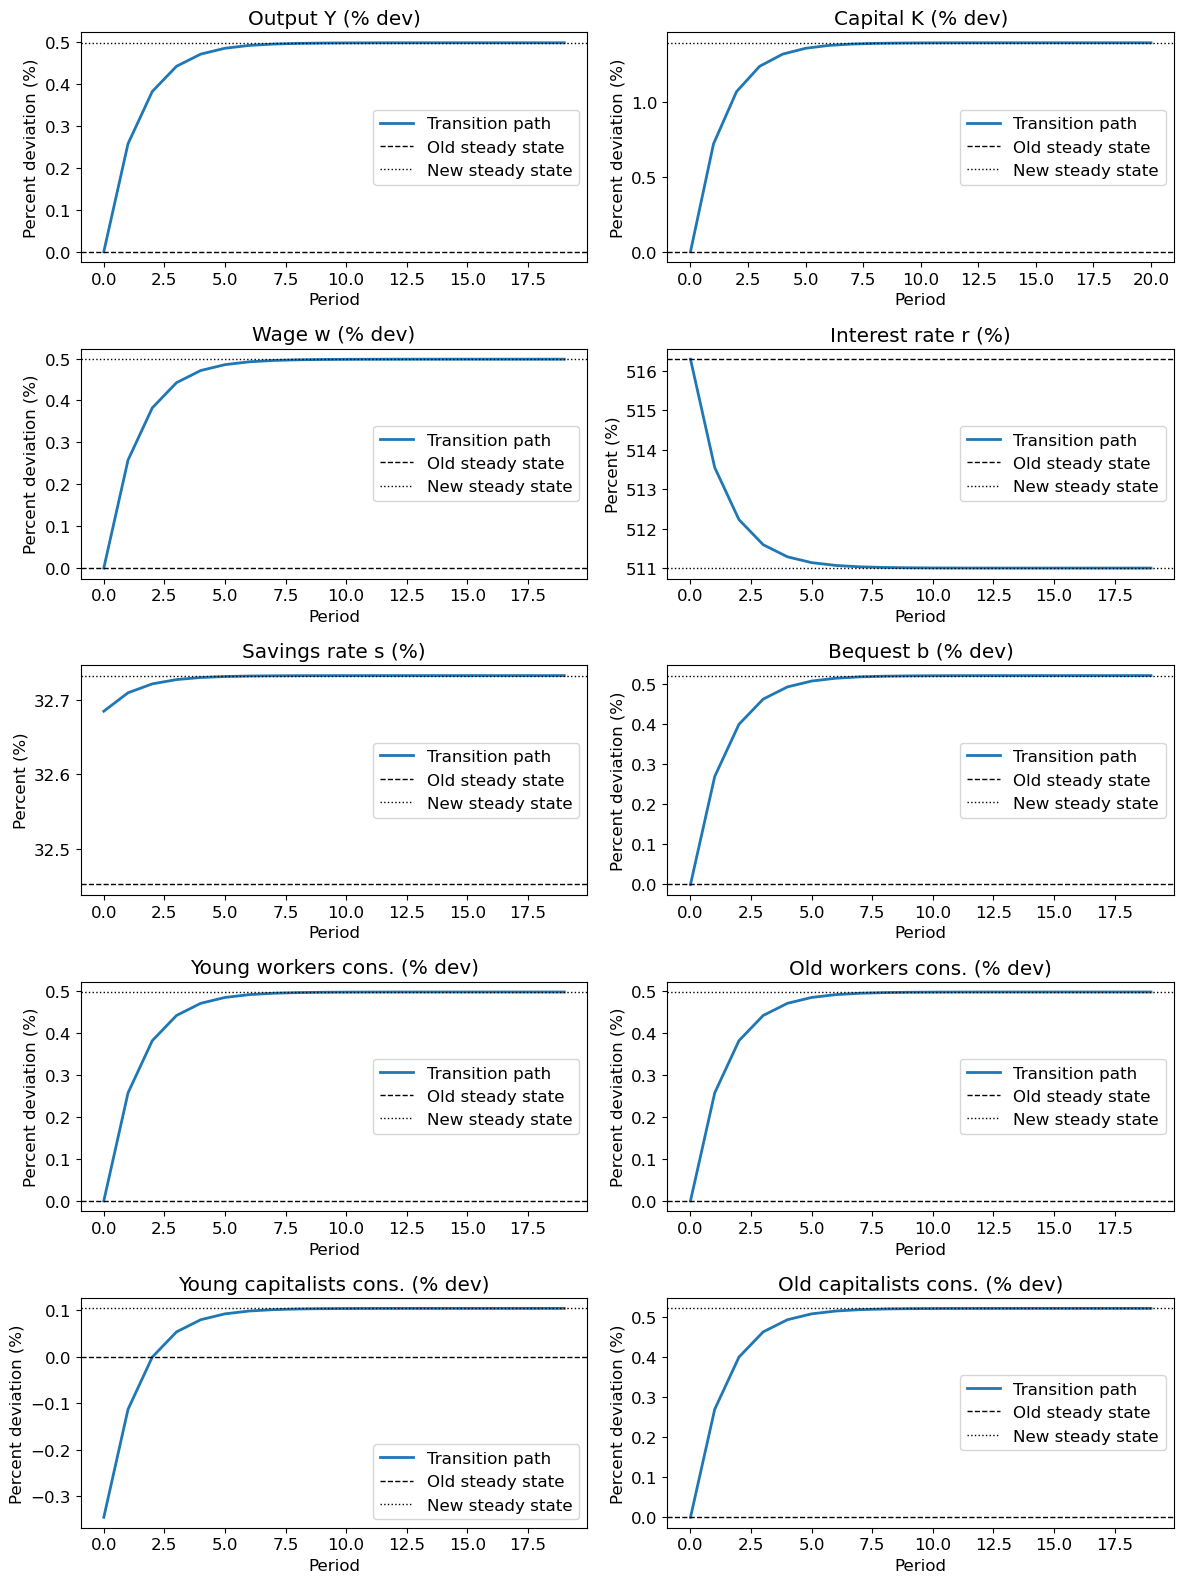

In [ ]:
# Simulation
sim_unc = simulate_olg(ss.K, 20, par_unc, euler_fun=euler_err_uncertain)

print("Transition under uncertainty")
print("-------------------------------------------")
print(f"Initial capital:                 {sim_unc.K[0]:.6f}")
print(f"Final capital after simulation:  {sim_unc.K[-1]:.6f}")
print(f"Uncertain steady-state capital:  {ss_unc.K:.6f}")
print(f"Max abs goods-market residual:   {np.max(np.abs(sim_unc.goods_mkt_err)):.4e}")

# Plot graphs from simulation
plot_simulation(sim_unc, ss, ss_unc)

### Task 6.5 - Comparison of steady states

#### Results

| | Part 2 (no tax) | Part 5 (optimal tax $\tau_a^* = 4.06\%$) | Part 6 (uncertainty, no actual tax) |
|---|---|---|---|
| $K$ | 0.004922 | 0.004643 | 0.004991 |
| Compared to Part 2 | baseline | lower | higher |

#### Interpretation
The ordering $K_5 < K^* < K_6$ captures the key distinction: an actual tax reduces 
capital by distorting realized returns, while tax uncertainty increases capital by 
triggering precautionary saving.

In Part 5, a permanent wealth tax of $\tau_a^* = 4.06\%$ is actually paid every period.
This reduces the after-tax return on saving and erodes bequests across generations. Since capitalists inherit less and earn less on what they save, the optimal 
response is to accumulate less capital. The economy settles at $K_5 = 0.004638$, down 
5.78% from baseline.

In Part 6, no tax is ever paid, but capitalists expect a 50% chance of being taxed next
period. Because agents are prudent under CRRA with $\gamma = 2.1 > 1$, uncertainty alone
is enough to increase saving as a precautionary buffer. Capital therefore rises to
$K_{unc} = 0.004991$, above even the no-tax baseline.

To conclude, a certain tax lowers capital through distortion of actual returns,
while tax uncertainty raises capital through expectations alone.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 6:**

 - The code in part 6 executes without error. 

 - Part 6 is easy to follow and well-structured. Markdown-cells for each subtask and seperation between steady-state and transition provides a clear presentation of the different states.

 - Functions are once again reused and modified to fit the task, as asked for in the task. Code is not duplicated and consistend with prevoius parts of the solution.

 - A loop is used for simulating the transition to the uncertain state, where vectorization could have improved the efficiency of the code.

 - The results are consistent with the solution, with clear interpretations for both the actual tax and uncertainty regarding future tax. The numerical results are not identical to those from Canvas due to rounding, alhough they confirm the correct implementation and economic theory. 

---
## AI Declaration
---

We used AI to assist in troubleshooting and structuring of this assignment.
AI was not used for interpreting or explaining results, which were done independently.